# 07 — SHAP Feature Importance Analysis

**Pipeline position:** Step 7 of 7

**Purpose:** Compute TreeSHAP values for the XGBoost bootstrap ensemble,
combining Gain, Weight, and mean |SHAP| importance across three dataset splits.
Produces publication-quality summary plots, dependence plots, and an interaction
heatmap.

**License:** MIT

## Prerequisites
- Run `05_bootstrap_ensemble.ipynb` first
- Inputs: `data_*_selected.csv`, `./bootstrap_models/model_*.pkl`

## Outputs
- `./outputs_fi/` — feature importance CSV, interaction CSV, and figures


In [ ]:
# SPDX-License-Identifier: MIT
# ============================================================
# Dependency check — run this cell first
# ============================================================
import importlib.util

_required = ['numpy', 'pandas', 'sklearn', 'xgboost', 'matplotlib', 'seaborn', 'scipy', 'openpyxl']
_missing = [p for p in _required if importlib.util.find_spec(p) is None]
if _missing:
    raise ImportError(
        f"Missing packages: {_missing}\n"
        f"Install with: pip install {' '.join(_missing)}"
    )
print("Core dependencies satisfied.")

if importlib.util.find_spec('shap') is None:
    print("WARNING: 'shap' not installed — run: pip install shap")
else:
    import shap
    print(f"  shap {getattr(shap, '__version__', 'ok')}")

# Optimized Feature Importance & SHAP Analysis (Self-Contained)

**This notebook is fully self-contained** — includes data loading, model loading, and all analysis.

**Enhancements over original pipeline:**

1. **SHAP Deep Analysis** — TreeSHAP with per-split computation (Train/Val/Test), interaction effects, dependence plots
2. **Multi-Method Fusion** — Gain, Weight, SHAP with weighted rank-correlation analysis
3. **SHAP Stability** — Bootstrap 95% CI for mean |SHAP| via model subsampling
4. **Feature Interaction** — SHAP interaction values to detect synergistic feature pairs
5. **Split-Aware SHAP** — Compare feature contributions across Train/Val/Test for generalization check
6. **Publication-Ready** — All figures 300 DPI TIFF, consistent clinical-group color coding

---
## §0 — Setup: Imports, Configuration, Data Loading, Model Loading

Runs all prerequisite steps from the original pipeline.

In [46]:
# ============================================================
# §0a — Imports
# ============================================================

from __future__ import annotations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from scipy import stats
from tqdm import tqdm
import pickle, os, gc, warnings

warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

try:
    import shap
    SHAP_AVAILABLE = True
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    SHAP_AVAILABLE = False
    print("WARNING: SHAP not installed. Run: pip install shap")

# ============================================================
# §0b — Configuration
# ============================================================
OUTCOME       = 'SpontAbortion'
RANDOM_STATE = 42
N_MODELS      = 300
MODEL_DIR     = "./bootstrap_models"

# Feature importance config
FI_DPI          = 300
FI_TOP_N        = 25
SHAP_SUBSAMPLE  = 500000
SHAP_N_MODELS   = 50
OUTPUT_DIR      = "./outputs_fi"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Imports & config done.")

SHAP version: 0.47.1
Imports & config done.


In [47]:
# ============================================================
# §0c — Data Loading & Encoding
# ============================================================

TRAIN_FILE   = "data_training_selected.csv"
INTVAL_FILE  = "data_internal_validation_selected.csv"
TEMPVAL_FILE = "data_temporal_validation_selected.csv"

df_train_raw = pd.read_csv(TRAIN_FILE)
df_val_raw   = pd.read_csv(INTVAL_FILE)
df_test_raw  = pd.read_csv(TEMPVAL_FILE)

drop_cols = ['Index', 'BaseInfoDate', 'Dataset']

def encode_all(df_train, df_val, df_test):
    dfs = {"train": df_train.copy(), "val": df_val.copy(), "test": df_test.copy()}
    for name in dfs:
        dfs[name] = dfs[name].drop(
            columns=[c for c in drop_cols if c in dfs[name].columns], errors='ignore'
        )
    for name in dfs:
        df = dfs[name]
        if df[OUTCOME].dtype == bool:
            df[OUTCOME] = df[OUTCOME].astype(int)
        elif df[OUTCOME].dtype == object:
            df[OUTCOME] = df[OUTCOME].map({'True':1,'False':0,'TRUE':1,'FALSE':0}).astype(int)
        else:
            df[OUTCOME] = pd.to_numeric(df[OUTCOME], errors='coerce').astype(int)
    for name in dfs:
        for col in dfs[name].select_dtypes(include=['bool']).columns:
            dfs[name][col] = dfs[name][col].astype(int)
    feature_cols = [c for c in dfs["train"].columns if c != OUTCOME]
    obj_cols = [c for c in feature_cols if dfs["train"][c].dtype == object]
    print(f"  LabelEncoder columns: {obj_cols}")
    label_encoders = {}
    for col in obj_cols:
        le = LabelEncoder()
        train_vals = dfs["train"][col].astype(str)
        le.fit(train_vals)
        label_encoders[col] = le
        most_freq = train_vals.mode()[0]
        known = set(le.classes_)
        for name in dfs:
            col_str = dfs[name][col].astype(str)
            col_safe = col_str.where(col_str.isin(known), most_freq)
            dfs[name][col] = le.transform(col_safe).astype(np.float64)
    for name in dfs:
        for col in feature_cols:
            if col not in obj_cols:
                dfs[name][col] = pd.to_numeric(dfs[name][col], errors='coerce')
    for name in dfs:
        n0 = len(dfs[name])
        dfs[name] = dfs[name].dropna()
        if len(dfs[name]) < n0:
            print(f"  {name}: dropped {n0 - len(dfs[name])} NaN rows")
    return dfs, feature_cols, label_encoders

dfs, features, label_encoders = encode_all(df_train_raw, df_val_raw, df_test_raw)

X_train = dfs["train"][features].astype(np.float32)
X_val   = dfs["val"][features].astype(np.float32)
X_test  = dfs["test"][features].astype(np.float32)
y_train = dfs["train"][OUTCOME].astype(int)
y_val   = dfs["val"][OUTCOME].astype(int)
y_test  = dfs["test"][OUTCOME].astype(int)

print(f"\nFeatures : {len(features)}")
print(f"Train    : N={len(y_train):>7,}  SA={y_train.sum():>5,} ({y_train.mean()*100:.2f}%)")
print(f"Val      : N={len(y_val):>7,}  SA={y_val.sum():>5,} ({y_val.mean()*100:.2f}%)")
print(f"Test     : N={len(y_test):>7,}  SA={y_test.sum():>5,} ({y_test.mean()*100:.2f}%)")

  LabelEncoder columns: ['HusbandEdu', 'WifeEdu', 'HusbandOcc', 'WifeOcc']

Features : 36
Train    : N=360,363  SA=11,753 (3.26%)
Val      : N= 40,041  SA=1,306 (3.26%)
Test     : N=  1,822  SA=  262 (14.38%)


In [48]:
# ============================================================
# §0d — Load 300 Bootstrap Models from Disk
# ============================================================

def load_models_from_disk(model_dir='./bootstrap_models', n_models=None):
    model_files = sorted([f for f in os.listdir(model_dir) if f.endswith('.pkl')])
    if n_models is not None:
        model_files = model_files[:n_models]
    models = []
    print(f"Loading {len(model_files)} models from {model_dir}...")
    for model_file in tqdm(model_files, desc="Loading models"):
        model_path = os.path.join(model_dir, model_file)
        with open(model_path, 'rb') as f:
            models.append(pickle.load(f))
    print(f"Successfully loaded {len(models)} models")
    return models

models = load_models_from_disk(model_dir=MODEL_DIR, n_models=N_MODELS)
print(f"\nReady: {len(models)} models × {len(features)} features")

Loading 300 models from ./bootstrap_models...


Loading models: 100%|██████████| 300/300 [00:06<00:00, 45.79it/s]


Successfully loaded 300 models

Ready: 300 models × 36 features


In [49]:
# ============================================================
# §0e — Variable Labels & Clinical Groups (for plotting)
# ============================================================

_VAR_LABELS = {
    "WifeAge": "Wife Age", "HusbandAge": "Husband Age", "MenarcheAge": "Menarche Age",
    "WifeHeight": "Wife Height", "WifeBMI": "Wife BMI",
    "WifeHR": "Wife HR", "WifeSBP": "Wife SBP", "WifeDBP": "Wife DBP",
    "HusbHeight": "Husb Height", "HusbBMI": "Husb BMI",
    "HusbHR": "Husb HR", "HusbSBP": "Husb SBP", "HusbDBP": "Husb DBP",
    "Hemoglobin": "Hemoglobin", "RBC": "RBC", "Platelet": "Platelet", "WBC": "WBC",
    "NeutrophilPct": "Neutrophil%", "LymphocytePct": "Lymphocyte%",
    "Glucose": "Glucose", "WifeALT": "Wife ALT", "WifeCreat": "Wife Creat",
    "TSH": "TSH", "HusbALT": "Husb ALT", "HusbCreat": "Husb Creat",
    "LeftTestVol": "L.TestVol", "RightTestVol": "R.TestVol",
    "WifeEdu": "Wife Edu", "HusbandEdu": "Husb Edu",
    "WifeOcc": "Wife Occ", "HusbandOcc": "Husb Occ",
    "PrevPregnancy": "Prev Preg", "Consanguinity": "Consanguinity",
    "GynDisease": "Gyn Disease", "GynUltrasound": "Gyn US",
    "WifeSmoke": "Wife Smoke", "HusbSmoke": "Husb Smoke",
    "WifeAlcohol": "Wife Alcohol", "HusbAlcohol": "Husb Alcohol",
    "WifePassSmoke": "Wife PassSmoke", "HusbPassSmoke": "Husb PassSmoke",
}

_VAR_GROUPS = {
    "Demographics": ["WifeAge","HusbandAge","WifeEdu","HusbandEdu","WifeOcc","HusbandOcc",
                      "WifeEthnic","HusbandEthnic","WifeResident","HusbandResident"],
    "Wife Physical": ["WifeHeight","WifeBMI","WifeHR","WifeSBP","WifeDBP",
                       "WifeMental","WifeIntel","WifeFace","WifePosture","WifeFaceSpec","WifeSkinHair",
                       "WifeThyroid","WifeLung","WifeRhythm","WifeMurmur","WifeLiverSpleen","WifeExtremity"],
    "Husband Physical": ["HusbHeight","HusbBMI","HusbHR","HusbSBP","HusbDBP",
                          "HusbMental","HusbIntel","HusbFace","HusbPosture","HusbFaceSpec","HusbSkinHair",
                          "HusbThyroid","HusbLung","HusbRhythm","HusbMurmur","HusbLiverSpleen","HusbExtremity"],
    "Reproduction": ["MenarcheAge","CycleRegular","MenstrualVol","Dysmenorrhea",
                      "PrevPregnancy","Contraception","WifeGynExam","GynUltrasound",
                      "WifePubHair","Breast","Vulva","GynDisease"],
    "Andrology": ["HusbPubHair","AdamsApple","Penis","Foreskin","Testis","Epididymis",
                   "VasDeferens","Varicocele","LeftTestVol","RightTestVol","HusbAndroExam","HusbAndrologyDis"],
    "Lab Tests": ["Hemoglobin","RBC","Platelet","WBC","NeutrophilPct","LymphocytePct",
                   "Glucose","WifeALT","WifeCreat","HusbALT","HusbCreat","TSH"],
    "Blood Type": ["WifeABO","HusbABO","WifeRh","HusbRh"],
    "Infection": ["RubellaIgG","CMVIgG","CMVIgM","ToxoIgG","ToxoIgM",
                   "SyphilisScr","HusbSyphilis","WifeHepB","HusbHepB","WifeUrine","HusbUrine"],
    "Medical Hx": ["WifeDiseaseHx","WifeBirthDefect","WifeMedication","WifeVaccine",
                    "WifeFamConsang","WifeFamDisease","Consanguinity",
                    "HusbDiseaseHis","HusbBirthDefect","HusbMedication","HusbVaccinated",
                    "HusbFamConsang","HusbFamDisease"],
    "Lifestyle": ["WifeMeatEgg","WifeVegAverse","WifeRawMeat","WifeSmoke","WifePassSmoke",
                   "WifeAlcohol","WifeDrugUse","WifeHalitosis","WifeGumBleed",
                   "HusbMeatEgg","HusbVegAverse","HusbRawMeat","HusbSmoke","HusbPassSmoke",
                   "HusbAlcohol","HusbDrugUse"],
    "Psychosocial": ["WifeEnvExpose","WifeStress","WifeRelatStress","WifeFinance","WifeReady",
                      "HusbEnvExpose","HusbStress","HusbRelatStress","HusbFinance","HusbReady"],
}

def _lbl(v): return _VAR_LABELS.get(v, v)
def _grp(v):
    for g, vs in _VAR_GROUPS.items():
        if v in vs: return g
    return "Other"

_GROUP_PALETTE = {
    "Demographics": "#4e79a7", "Wife Physical": "#f28e2b", "Husband Physical": "#e15759",
    "Reproduction": "#76b7b2", "Andrology": "#59a14f", "Lab Tests": "#edc948",
    "Blood Type": "#b07aa1", "Infection": "#ff9da7", "Medical Hx": "#9c755f",
    "Lifestyle": "#bab0ac", "Psychosocial": "#86bcb6", "Other": "#cccccc",
}

print("Labels & groups loaded.")

Labels & groups loaded.


---
## §1 — Gain & Weight Importance (300 Bootstrap Models)

In [50]:
"""
§1 — Extract Gain & Weight importance with stability metrics

Improvements over original:
  - Coefficient of Variation (CV) for stability assessment
  - Feature usage rate across models
  - Robust aggregation (median + IQR alongside mean ± SD)
"""

def extract_gain_importance(models, feature_names):
    """Extract gain and weight importance from all bootstrap models."""
    n_models = len(models)
    n_feats = len(feature_names)
    gain_matrix = np.zeros((n_models, n_feats))
    weight_matrix = np.zeros((n_models, n_feats))
    fname_to_idx = {f: i for i, f in enumerate(feature_names)}

    for i, model in enumerate(tqdm(models, desc="Extracting Gain/Weight")):
        booster = model.get_booster()
        for imp_type, matrix in [("gain", gain_matrix), ("weight", weight_matrix)]:
            scores = booster.get_score(importance_type=imp_type)
            for key, val in scores.items():
                if key in fname_to_idx:
                    matrix[i, fname_to_idx[key]] = val
                else:
                    try:
                        idx = int(key.replace("f", ""))
                        if idx < n_feats:
                            matrix[i, idx] = val
                    except ValueError:
                        pass

    row_sums = gain_matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    gain_norm = gain_matrix / row_sums
    return gain_matrix, gain_norm, weight_matrix


print(f"Extracting importance from {len(models)} models × {len(features)} features...")
gain_raw, gain_norm, weight_raw = extract_gain_importance(models, features)

df_fi = pd.DataFrame({
    "Feature": features,
    "Label": [_lbl(f) for f in features],
    "Group": [_grp(f) for f in features],
    "Gain_Mean":   gain_norm.mean(axis=0),
    "Gain_SD":     gain_norm.std(axis=0),
    "Gain_Median": np.median(gain_norm, axis=0),
    "Gain_Q25":    np.percentile(gain_norm, 25, axis=0),
    "Gain_Q75":    np.percentile(gain_norm, 75, axis=0),
    "Gain_CV":     gain_norm.std(axis=0) / (gain_norm.mean(axis=0) + 1e-10),
    "Weight_Mean": weight_raw.mean(axis=0),
    "Weight_SD":   weight_raw.std(axis=0),
    "N_Models_Used": (gain_raw > 0).sum(axis=0),
    "Usage_Rate":    (gain_raw > 0).sum(axis=0) / len(models) * 100,
}).sort_values("Gain_Mean", ascending=False).reset_index(drop=True)

print(f"\nTop 15 features by Gain (mean ± SD):")
print(df_fi[["Feature", "Label", "Gain_Mean", "Gain_SD", "Gain_CV", "Usage_Rate"]].head(15).to_string(index=False))

Extracting importance from 300 models × 36 features...


Extracting Gain/Weight: 100%|██████████| 300/300 [00:01<00:00, 243.74it/s]


Top 15 features by Gain (mean ± SD):
      Feature         Label  Gain_Mean  Gain_SD  Gain_CV  Usage_Rate
      WifeAge      Wife Age   0.062077 0.009371 0.150959       100.0
Contraception Contraception   0.058427 0.015214 0.260398       100.0
PrevPregnancy     Prev Preg   0.047534 0.016884 0.355202       100.0
GynUltrasound        Gyn US   0.034733 0.008338 0.240070       100.0
  WifeFinance   WifeFinance   0.034103 0.007507 0.220127       100.0
   HusbandAge   Husband Age   0.031237 0.006090 0.194974       100.0
       CMVIgG        CMVIgG   0.027165 0.004211 0.155008       100.0
 Dysmenorrhea  Dysmenorrhea   0.026167 0.004446 0.169897       100.0
 RightTestVol     R.TestVol   0.025853 0.002080 0.080452       100.0
  LeftTestVol     L.TestVol   0.025816 0.001912 0.074052       100.0
      HusbDBP      Husb DBP   0.025258 0.001713 0.067803       100.0
      WifeDBP      Wife DBP   0.024836 0.001601 0.064477       100.0
   HusbandEdu      Husb Edu   0.024815 0.002656 0.107032       10

---
## §2 — Enhanced SHAP Analysis (Per-Split with Bootstrap CI)

In [51]:
"""
§2 — SHAP Values: Per-Split Computation with Bootstrap CI

Key improvements over original:
  - Per-split SHAP (Train/Val/Test) to check generalization
  - Bootstrap 95% CI for mean|SHAP| via model subsampling
  - Per-model SHAP variance for epistemic uncertainty
"""

def compute_shap_values(
    models, X, feature_names,
    n_subsample=3000, n_models_shap=50, random_state=42,
    desc="Computing SHAP"
):
    """
    Compute SHAP values with bootstrap uncertainty.

    Returns
    -------
    shap_mean      : (n_sub, n_features) — averaged SHAP values across models
    shap_per_model : (n_models_shap, n_sub, n_features) — individual model SHAP
    X_sub          : (n_sub, n_features) — subsampled feature matrix
    sub_idx        : indices used for subsampling
    """
    rng = np.random.RandomState(random_state)
    n_sub = min(n_subsample, len(X))
    sub_idx = rng.choice(len(X), n_sub, replace=False)
    X_sub = X.values[sub_idx] if hasattr(X, 'values') else X[sub_idx]

    n_m = min(n_models_shap, len(models))
    model_idx = rng.choice(len(models), n_m, replace=False)

    shap_per_model = []
    for mi in tqdm(model_idx, desc=desc):
        explainer = shap.TreeExplainer(models[mi])
        sv = explainer.shap_values(X_sub)
        shap_per_model.append(sv)

    shap_per_model = np.array(shap_per_model)  # (n_models, n_sub, n_feats)
    shap_mean = shap_per_model.mean(axis=0)      # (n_sub, n_feats)
    return shap_mean, shap_per_model, X_sub, sub_idx


if SHAP_AVAILABLE:
    print("=" * 60)
    print("Computing SHAP values per split...")
    print("=" * 60)

    shap_train_mean, shap_train_per_model, X_shap_train, idx_shap_train = \
        compute_shap_values(models, X_train, features,
                            n_subsample=SHAP_SUBSAMPLE, n_models_shap=SHAP_N_MODELS,
                            random_state=RANDOM_STATE, desc="SHAP [Train]")

    shap_val_mean, shap_val_per_model, X_shap_val, _ = \
        compute_shap_values(models, X_val, features,
                            n_subsample=min(SHAP_SUBSAMPLE, len(X_val)),
                            n_models_shap=SHAP_N_MODELS,
                            random_state=RANDOM_STATE + 1, desc="SHAP [Val]")

    shap_test_mean, shap_test_per_model, X_shap_test, _ = \
        compute_shap_values(models, X_test, features,
                            n_subsample=min(SHAP_SUBSAMPLE, len(X_test)),
                            n_models_shap=SHAP_N_MODELS,
                            random_state=RANDOM_STATE + 2, desc="SHAP [Test]")

    # Aggregate statistics
    shap_abs_train = np.abs(shap_train_mean).mean(axis=0)
    shap_abs_val   = np.abs(shap_val_mean).mean(axis=0)
    shap_abs_test  = np.abs(shap_test_mean).mean(axis=0)

    # Per-model uncertainty
    shap_per_model_abs = np.abs(shap_train_per_model).mean(axis=1)  # (n_models, n_feats)
    shap_ci_lo = np.percentile(shap_per_model_abs, 2.5, axis=0)
    shap_ci_hi = np.percentile(shap_per_model_abs, 97.5, axis=0)

    # Merge into df_fi
    for col_name, arr in [("SHAP_Train", shap_abs_train), ("SHAP_Val", shap_abs_val),
                           ("SHAP_Test", shap_abs_test), ("SHAP_SD", shap_per_model_abs.std(axis=0)),
                           ("SHAP_CI_Lo", shap_ci_lo), ("SHAP_CI_Hi", shap_ci_hi)]:
        df_fi[col_name] = 0.0
        for i, f in enumerate(features):
            mask = df_fi["Feature"] == f
            if mask.any():
                df_fi.loc[mask, col_name] = arr[i]

    df_fi["SHAP_Mean"] = df_fi["SHAP_Train"]  # backward compat alias

    print(f"\nSHAP computed: Train={len(X_shap_train)}, Val={len(X_shap_val)}, Test={len(X_shap_test)} samples")
    print(f"Models used: {SHAP_N_MODELS}")
    print(f"\nTop 10 by mean|SHAP| (Training):")
    print(df_fi.sort_values("SHAP_Train", ascending=False)
          [["Feature","Label","SHAP_Train","SHAP_Val","SHAP_Test","SHAP_SD"]].head(10).to_string(index=False))
else:
    print("SHAP not available — skipping. Install with: pip install shap")

Computing SHAP values per split...


SHAP [Test]: 100%|██████████| 50/50 [00:21<00:00,  2.29it/s]



SHAP computed: Train=360363, Val=40041, Test=1822 samples
Models used: 50

Top 10 by mean|SHAP| (Training):
      Feature         Label  SHAP_Train  SHAP_Val  SHAP_Test  SHAP_SD
      WifeAge      Wife Age    0.313155  0.328234   0.311537 0.054105
PrevPregnancy     Prev Preg    0.130008  0.128904   0.121609 0.030673
Contraception Contraception    0.108506  0.111166   0.094287 0.028544
   HusbandAge   Husband Age    0.106685  0.092242   0.091533 0.036569
  WifeFinance   WifeFinance    0.095738  0.098354   0.086842 0.028286
    WifeCreat    Wife Creat    0.087806  0.088154   0.123248 0.034325
          TSH           TSH    0.086423  0.080819   0.126188 0.034810
      WifeBMI      Wife BMI    0.079804  0.079198   0.069851 0.038281
          RBC           RBC    0.079285  0.082348   0.095714 0.034428
NeutrophilPct   Neutrophil%    0.078441  0.074467   0.101400 0.033718


---
## §3 — Aggregated Ranking (Multi-Method Weighted Fusion)

In [52]:
"""
§3 — Multi-method aggregation with rank correlation

Improvements: weighted fusion, Spearman correlation matrix between methods
"""

norm_cols = ["Gain_Mean", "Weight_Mean"]
weights   = {"Gain_Mean": 0.35, "Weight_Mean": 0.15}

if SHAP_AVAILABLE:
    norm_cols.append("SHAP_Train")
    weights["SHAP_Train"] = 0.50

for col in norm_cols:
    mx = df_fi[col].max()
    df_fi[f"{col}_Norm"] = df_fi[col] / mx if mx > 0 else 0.0

total_weight = sum(weights.values())
df_fi["Aggregated"] = sum(df_fi[f"{col}_Norm"] * w for col, w in weights.items()) / total_weight

df_fi["Gain_Rank"]   = df_fi["Gain_Mean"].rank(ascending=False).astype(int)
df_fi["Weight_Rank"] = df_fi["Weight_Mean"].rank(ascending=False).astype(int)
if SHAP_AVAILABLE:
    df_fi["SHAP_Rank"] = df_fi["SHAP_Train"].rank(ascending=False).astype(int)

df_fi = df_fi.sort_values("Aggregated", ascending=False).reset_index(drop=True)
df_fi.insert(0, "Rank", range(1, len(df_fi) + 1))

# Spearman rank correlation
rank_cols = ["Gain_Rank", "Weight_Rank"] + (["SHAP_Rank"] if SHAP_AVAILABLE else [])
rank_corr = df_fi[rank_cols].corr(method="spearman")
print("Rank Correlation (Spearman) between methods:")
print(rank_corr.round(3).to_string())

print(f"\nWeights: {weights}")
print(f"\nFinal Top 15:")
show_cols = ["Rank", "Feature", "Label", "Group", "Aggregated", "Gain_Mean"]
if SHAP_AVAILABLE:
    show_cols += ["SHAP_Train", "SHAP_Val", "SHAP_Test"]
print(df_fi[show_cols].head(15).to_string(index=False))

Rank Correlation (Spearman) between methods:
             Gain_Rank  Weight_Rank  SHAP_Rank
Gain_Rank        1.000       -0.505      0.402
Weight_Rank     -0.505        1.000      0.345
SHAP_Rank        0.402        0.345      1.000

Weights: {'Gain_Mean': 0.35, 'Weight_Mean': 0.15, 'SHAP_Train': 0.5}

Final Top 15:
 Rank       Feature         Label            Group  Aggregated  Gain_Mean  SHAP_Train  SHAP_Val  SHAP_Test
    1       WifeAge      Wife Age     Demographics    0.919003   0.062077    0.313155  0.328234   0.311537
    2 Contraception Contraception     Reproduction    0.515093   0.058427    0.108506  0.111166   0.094287
    3 PrevPregnancy     Prev Preg     Reproduction    0.487757   0.047534    0.130008  0.128904   0.121609
    4           TSH           TSH        Lab Tests    0.423404   0.024018    0.086423  0.080819   0.126188
    5    HusbandAge   Husband Age     Demographics    0.419577   0.031237    0.106685  0.092242   0.091533
    6       WifeBMI      Wife BMI    Wif

---
## §4 — SHAP Beeswarm + Bar with 95% CI

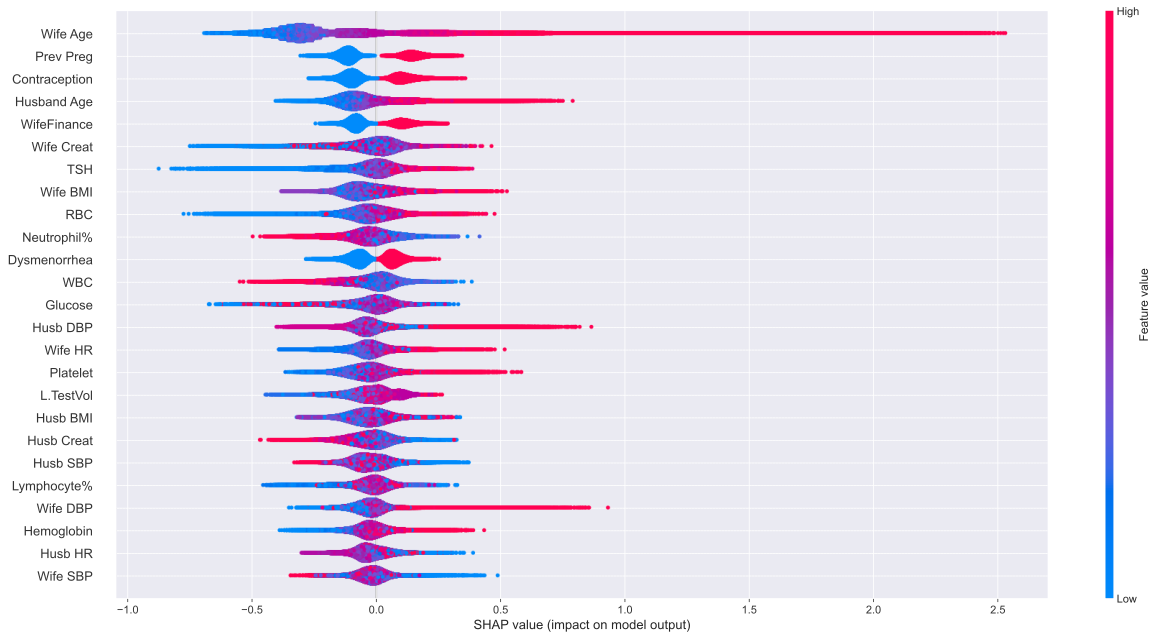

Saved: ./outputs_fi\shap_beeswarm_bar.tiff


In [53]:
"""
§4 — SHAP Beeswarm (direction) + Bar (magnitude with CI)
"""

if SHAP_AVAILABLE:
    # Sort features by SHAP_Train descending for beeswarm display
    top_shap_df = df_fi.head(FI_TOP_N).sort_values("SHAP_Train", ascending=False)
    top_features = top_shap_df["Feature"].tolist()
    top_feat_idx = [features.index(f) for f in top_features]

    shap_top = shap_train_mean[:, top_feat_idx]
    X_shap_df = pd.DataFrame(X_shap_train[:, top_feat_idx],
                              columns=[_lbl(f) for f in top_features])

    fig, axes = plt.subplots(1, 2, figsize=(18, max(7, FI_TOP_N * 0.36)),
                              gridspec_kw={"width_ratios": [1.3, 1]})

    # Left: Beeswarm
    plt.sca(axes[0])
    shap.summary_plot(shap_top, X_shap_df, plot_type="dot",
                      max_display=FI_TOP_N, show=False, plot_size=None)
    axes[0].set_title("SHAP Beeswarm — Feature Impact Direction",
                       fontsize=13, fontweight="bold", pad=10)
    axes[0].set_xlabel("SHAP Value (impact on log-odds)", fontsize=10)

    # Right: Bar with CI (sorted by SHAP_Train descending, plot bottom-to-top)
    ax_bar = axes[1]
    top_df = df_fi.head(FI_TOP_N).sort_values("SHAP_Train", ascending=True)  # ascending for bottom-to-top barh
    y_pos = np.arange(FI_TOP_N)
    colors = [_GROUP_PALETTE.get(g, "#ccc") for g in top_df["Group"]]

    ci_lo = np.clip(top_df["SHAP_Train"].values - top_df["SHAP_CI_Lo"].values, 0, None)
    ci_hi = np.clip(top_df["SHAP_CI_Hi"].values - top_df["SHAP_Train"].values, 0, None)

    ax_bar.barh(y_pos, top_df["SHAP_Train"].values,
                xerr=[ci_lo, ci_hi], height=0.65, color=colors, alpha=0.8,
                edgecolor="white", linewidth=0.5,
                error_kw=dict(elinewidth=0.8, capsize=2, color="#555"))
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(top_df["Label"].values, fontsize=9)
    ax_bar.set_xlabel("Mean |SHAP Value| (95% CI)", fontsize=10)
    ax_bar.set_title(f"SHAP Magnitude — {SHAP_N_MODELS} Models × {len(X_shap_train)} Samples",
                      fontsize=13, fontweight="bold", pad=10)
    ax_bar.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    fpath = os.path.join(OUTPUT_DIR, "shap_beeswarm_bar.tiff")
    plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fpath}")
else:
    print("SHAP not available.")

---
## §5 — Gain Boxplot + SHAP Bar (Side-by-Side)

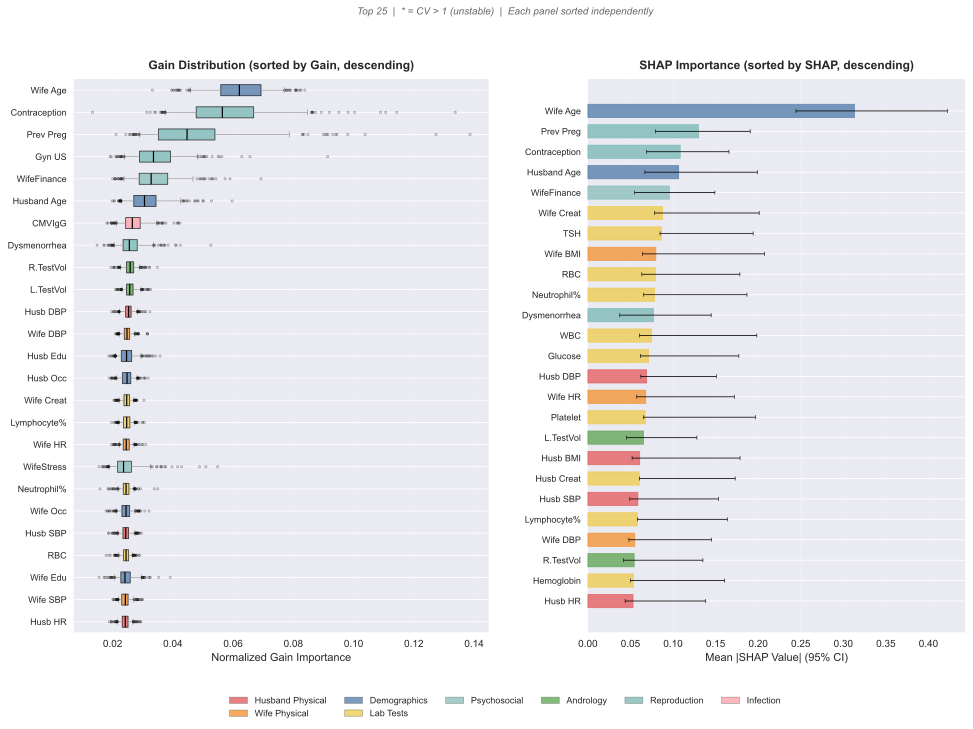

Saved: ./outputs_fi\gain_boxplot_shap_bar.tiff


In [54]:
"""
§5 — Gain Distribution (Boxplot) + SHAP Bar
     Left: sorted by Gain_Mean descending
     Right: sorted by SHAP_Train descending
"""

n_panels = 2 if SHAP_AVAILABLE else 1
fig, axes = plt.subplots(
    1, n_panels,
    figsize=(8 * n_panels, max(7, FI_TOP_N * 0.40)),
    gridspec_kw={"width_ratios": [1.1, 1][:n_panels], "wspace": 0.25},
)
if n_panels == 1:
    axes = [axes]

# ── Left panel: Gain Boxplot (sorted by Gain_Mean, largest at top) ──
df_gain_plot = df_fi.sort_values("Gain_Mean", ascending=False).head(FI_TOP_N).copy()
df_gain_plot = df_gain_plot.iloc[::-1].reset_index(drop=True)  # reverse for bottom-to-top barh

top_feats_gain = df_gain_plot["Feature"].tolist()
top_idx_gain = [features.index(f) for f in top_feats_gain]
box_data = gain_norm[:, top_idx_gain]

labels_gain = df_gain_plot["Label"].tolist()
colors_gain = [_GROUP_PALETTE.get(g, "#ccc") for g in df_gain_plot["Group"]]

ax_box = axes[0]
bp = ax_box.boxplot(
    box_data, vert=False, patch_artist=True, whis=[5, 95],
    boxprops=dict(linewidth=0.8),
    whiskerprops=dict(linewidth=0.6, color="#888"),
    capprops=dict(linewidth=0.6, color="#888"),
    medianprops=dict(color="black", linewidth=1.2),
    flierprops=dict(markersize=2, alpha=0.3),
)
for patch, color in zip(bp["boxes"], colors_gain):
    patch.set_facecolor(color); patch.set_alpha(0.75)

ax_box.set_yticklabels(labels_gain, fontsize=9)
ax_box.set_xlabel("Normalized Gain Importance", fontsize=11)
ax_box.set_title("Gain Distribution (sorted by Gain, descending)", fontsize=12, fontweight="bold", pad=10)
ax_box.grid(axis="x", alpha=0.2, linewidth=0.5)
# ax_box.invert_yaxis()

# Mark unstable features (CV > 1)
for j, feat in enumerate(top_feats_gain):
    cv = df_gain_plot.loc[df_gain_plot["Feature"] == feat, "Gain_CV"].values[0]
    if cv > 1.0:
        ax_box.text(box_data[:, j].max() * 1.02, j + 1, "*",
                    fontsize=12, color="red", va="center")

# ── Right panel: SHAP Bar (sorted by SHAP_Train, largest at top) ──
if SHAP_AVAILABLE:
    df_shap_plot = df_fi.sort_values("SHAP_Train", ascending=False).head(FI_TOP_N).copy()
    df_shap_plot = df_shap_plot.iloc[::-1].reset_index(drop=True)

    labels_shap = df_shap_plot["Label"].tolist()
    colors_shap = [_GROUP_PALETTE.get(g, "#ccc") for g in df_shap_plot["Group"]]

    ax_shap = axes[1]
    shap_means = df_shap_plot["SHAP_Train"].values
    ci_lo = np.clip(shap_means - df_shap_plot["SHAP_CI_Lo"].values, 0, None)
    ci_hi = np.clip(df_shap_plot["SHAP_CI_Hi"].values - shap_means, 0, None)
    y_pos = np.arange(len(df_shap_plot))

    ax_shap.barh(y_pos, shap_means, xerr=[ci_lo, ci_hi],
                 height=0.65, color=colors_shap, alpha=0.75,
                 edgecolor=colors_shap, linewidth=0.8,
                 error_kw=dict(elinewidth=0.8, capsize=2, capthick=0.6, color="#555"))
    ax_shap.set_yticks(y_pos)
    ax_shap.set_yticklabels(labels_shap, fontsize=9)
    ax_shap.set_xlabel("Mean |SHAP Value| (95% CI)", fontsize=11)
    ax_shap.set_title(f"SHAP Importance (sorted by SHAP, descending)",
                       fontsize=12, fontweight="bold", pad=10)
    ax_shap.grid(axis="x", alpha=0.2)

# Legend
all_groups = list(dict.fromkeys(
    df_gain_plot["Group"].tolist() + (df_shap_plot["Group"].tolist() if SHAP_AVAILABLE else [])
))
fig.legend(
    handles=[Patch(facecolor=_GROUP_PALETTE.get(g, "#ccc"), alpha=0.75, edgecolor="#666",
                    linewidth=0.5, label=g) for g in all_groups],
    loc="lower center", ncol=min(6, len(all_groups)), fontsize=9,
    frameon=False, bbox_to_anchor=(0.5, -0.02),
)
fig.text(0.5, 0.98, f"Top {FI_TOP_N}  |  * = CV > 1 (unstable)  |  Each panel sorted independently",
         ha="center", va="top", fontsize=10, style="italic", color="#666")

sns.despine(left=True)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
fpath = os.path.join(OUTPUT_DIR, "gain_boxplot_shap_bar.tiff")
plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


---
## §6 — Cross-Split SHAP Consistency

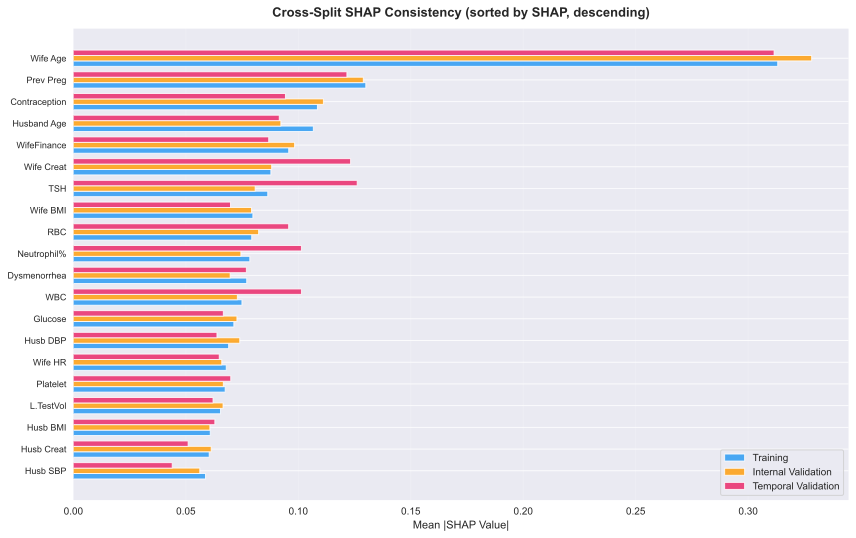

Saved: ./outputs_fi\shap_cross_split.tiff

SHAP Rank Correlation (Spearman):
  Train vs Val:   rho=0.991  (p=2.82e-31)
  Train vs Test:  rho=0.930  (p=2.28e-16)
  Val   vs Test:  rho=0.934  (p=1.02e-16)


In [55]:
"""
§6 — Cross-Split SHAP Consistency: Train vs Val vs Test

NEW: Check whether feature importance generalizes across splits.
"""

if SHAP_AVAILABLE:
    top_n_cross = min(20, FI_TOP_N)
    df_cross = df_fi.sort_values("SHAP_Train", ascending=False).head(top_n_cross).iloc[::-1].copy()

    fig, ax = plt.subplots(figsize=(12, max(6, top_n_cross * 0.38)))
    y_pos = np.arange(top_n_cross)
    bar_h = 0.25

    for col, label, color, offset in [
        ("SHAP_Train", "Training",            "#2196F3", -bar_h),
        ("SHAP_Val",   "Internal Validation",  "#FF9800",  0),
        ("SHAP_Test",  "Temporal Validation",   "#E91E63",  bar_h),
    ]:
        ax.barh(y_pos + offset, df_cross[col].values,
                height=bar_h, label=label, color=color, alpha=0.8, edgecolor="white")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_cross["Label"].values, fontsize=9)
    ax.set_xlabel("Mean |SHAP Value|", fontsize=11)
    ax.set_title("Cross-Split SHAP Consistency (sorted by SHAP, descending)",
                  fontsize=13, fontweight="bold", pad=12)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(axis="x", alpha=0.2)
    sns.despine(left=True)
    plt.tight_layout()
    fpath = os.path.join(OUTPUT_DIR, "shap_cross_split.tiff")
    plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fpath}")

    # Rank correlation
    r_tv, p_tv = stats.spearmanr(df_fi["SHAP_Train"].rank(ascending=False),
                                  df_fi["SHAP_Val"].rank(ascending=False))
    r_tt, p_tt = stats.spearmanr(df_fi["SHAP_Train"].rank(ascending=False),
                                  df_fi["SHAP_Test"].rank(ascending=False))
    r_vt, p_vt = stats.spearmanr(df_fi["SHAP_Val"].rank(ascending=False),
                                  df_fi["SHAP_Test"].rank(ascending=False))
    print(f"\nSHAP Rank Correlation (Spearman):")
    print(f"  Train vs Val:   rho={r_tv:.3f}  (p={p_tv:.2e})")
    print(f"  Train vs Test:  rho={r_tt:.3f}  (p={p_tt:.2e})")
    print(f"  Val   vs Test:  rho={r_vt:.3f}  (p={p_vt:.2e})")
else:
    print("SHAP not available.")

---
## §7 — SHAP Dependence Plots (Top Features)

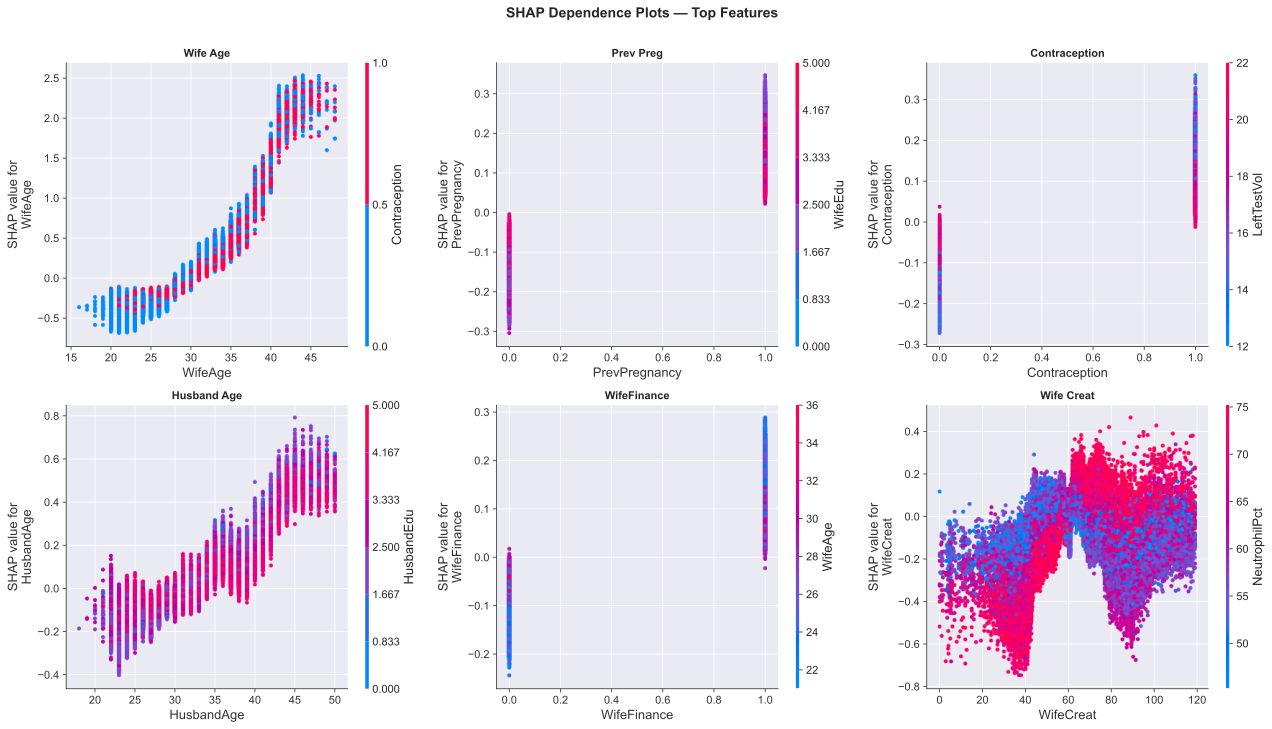

Saved: ./outputs_fi\shap_dependence.tiff


In [56]:
"""
§7 — SHAP Dependence Plots for Top 6 features

NEW: Non-linear feature→SHAP relationships with auto interaction coloring.
"""

if SHAP_AVAILABLE:
    n_dep = min(6, FI_TOP_N)
    top_dep = df_fi.sort_values("SHAP_Train", ascending=False).head(n_dep)["Feature"].tolist()
    top_dep_idx = [features.index(f) for f in top_dep]
    X_dep_df = pd.DataFrame(X_shap_train, columns=features)

    n_rows = (n_dep + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for k, (feat, fidx) in enumerate(zip(top_dep, top_dep_idx)):
        ax = axes_flat[k]
        plt.sca(ax)
        shap.dependence_plot(fidx, shap_train_mean, X_dep_df,
                              interaction_index="auto", ax=ax, show=False)
        ax.set_title(f"{_lbl(feat)}", fontsize=11, fontweight="bold")

    for k in range(n_dep, len(axes_flat)):
        axes_flat[k].set_visible(False)

    plt.suptitle("SHAP Dependence Plots — Top Features",
                  fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    fpath = os.path.join(OUTPUT_DIR, "shap_dependence.tiff")
    plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fpath}")
else:
    print("SHAP not available.")

---
## §8 — SHAP Interaction Analysis

Computing SHAP interaction values (may take a few minutes)...

Top 15 Feature Interactions:
           Feature A             Feature B   Interaction
--------------------------------------------------------
         Neutrophil%            Wife Creat       0.03221
         Lymphocyte%            Wife Creat       0.02872
                 WBC              Platelet       0.02743
            Husb DBP               Glucose       0.02669
         Neutrophil%            Husb Creat       0.02376
                 RBC            Husb Creat       0.02334
            Husb BMI            Wife Creat       0.02323
            Husb BMI            Husb Creat       0.02314
                 RBC               Wife HR       0.02275
                 WBC            Wife Creat       0.02253
          Wife Creat              Platelet       0.02243
          Hemoglobin              Platelet       0.02181
                 RBC            Wife Creat       0.02178
         Neutrophil%               Glucose       0.02

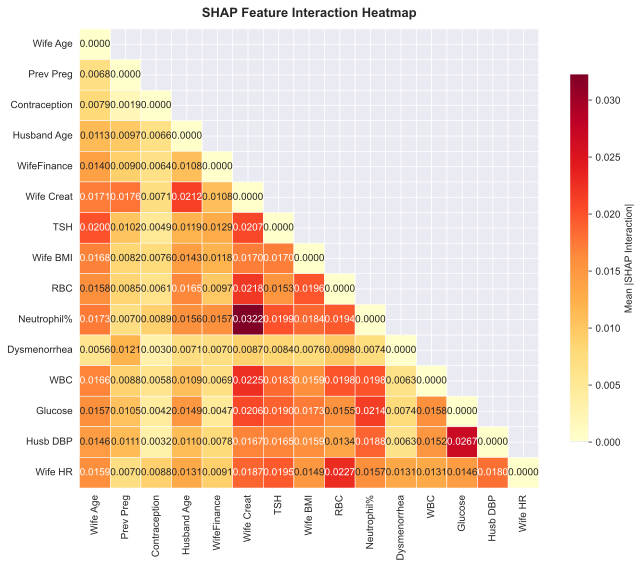

Saved: ./outputs_fi\shap_interaction_heatmap.tiff


In [57]:
"""
§8 — SHAP Interaction Values: identify strongest feature-feature synergies
"""

if SHAP_AVAILABLE:
    print("Computing SHAP interaction values (may take a few minutes)...")
    n_interact = min(500, len(X_shap_train))
    rng_int = np.random.RandomState(RANDOM_STATE)
    X_interact = X_shap_train[rng_int.choice(len(X_shap_train), n_interact, replace=False)]

    mid_model = models[len(models) // 2]
    explainer_int = shap.TreeExplainer(mid_model)

    try:
        shap_interaction = explainer_int.shap_interaction_values(X_interact)
        mean_interact = np.abs(shap_interaction).mean(axis=0)
        np.fill_diagonal(mean_interact, 0)

        # Top pairs
        n_f = len(features)
        pairs = sorted(
            [(features[i], features[j], mean_interact[i, j])
             for i in range(n_f) for j in range(i+1, n_f)],
            key=lambda x: x[2], reverse=True
        )
        print(f"\nTop 15 Feature Interactions:")
        print(f"{'Feature A':>20s}  {'Feature B':>20s}  {'Interaction':>12s}")
        print("-" * 56)
        for a, b, v in pairs[:15]:
            print(f"{_lbl(a):>20s}  {_lbl(b):>20s}  {v:12.5f}")

        # Heatmap
        top_int_n = min(15, FI_TOP_N)
        top_int_feats = df_fi.sort_values("SHAP_Train", ascending=False).head(top_int_n)["Feature"].tolist()
        top_int_idx = [features.index(f) for f in top_int_feats]
        hm = mean_interact[np.ix_(top_int_idx, top_int_idx)]
        hm_df = pd.DataFrame(hm, index=[_lbl(f) for f in top_int_feats],
                              columns=[_lbl(f) for f in top_int_feats])

        fig, ax = plt.subplots(figsize=(10, 8))
        mask = np.triu(np.ones_like(hm, dtype=bool), k=1)
        sns.heatmap(hm_df, mask=mask, annot=True, fmt=".4f", cmap="YlOrRd",
                    square=True, linewidths=0.5,
                    cbar_kws={"label": "Mean |SHAP Interaction|", "shrink": 0.8}, ax=ax)
        ax.set_title("SHAP Feature Interaction Heatmap", fontsize=13, fontweight="bold", pad=12)
        plt.tight_layout()
        fpath = os.path.join(OUTPUT_DIR, "shap_interaction_heatmap.tiff")
        plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fpath}")
    except Exception as e:
        print(f"Interaction failed: {e}\nSkipping (may happen with GPU-trained models).")
else:
    print("SHAP not available.")

---
## §9 — Gain vs SHAP Rank Comparison (Bump Chart)

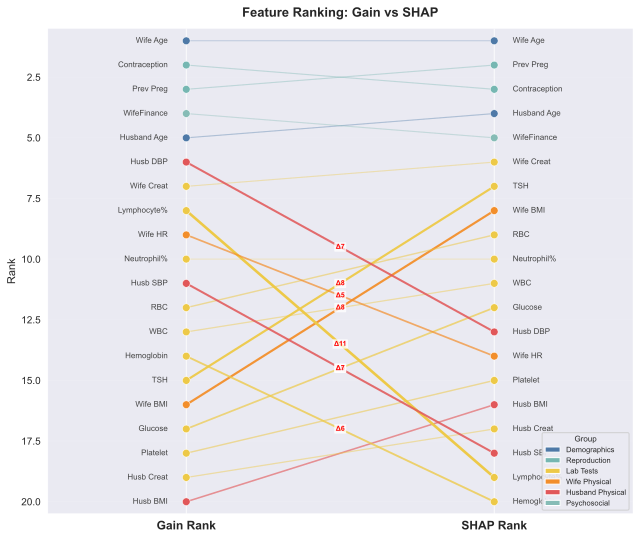

Saved: ./outputs_fi\rank_bump_gain_vs_shap.tiff


In [58]:
"""
§9 — Bump chart: line intensity ∝ rank discrepancy, big shifts annotated.
"""

if SHAP_AVAILABLE:
    n_bump = min(FI_TOP_N, 20)
    df_bump = df_fi.head(n_bump).copy()
    df_bump["_GR"] = df_bump["Gain_Mean"].rank(ascending=False).astype(int)
    df_bump["_SR"] = df_bump["SHAP_Train"].rank(ascending=False).astype(int)
    df_bump["_D"]  = np.abs(df_bump["_GR"] - df_bump["_SR"])

    fig, ax = plt.subplots(figsize=(9, max(7, n_bump * 0.38)))
    for _, row in df_bump.iterrows():
        c = _GROUP_PALETTE.get(row["Group"], "#ccc")
        a = min(0.3 + row["_D"] * 0.08, 1.0)
        ax.plot([0, 1], [row["_GR"], row["_SR"]], color=c, alpha=a, linewidth=1.0 + row["_D"] * 0.15)
        ax.scatter(0, row["_GR"], color=c, s=60, zorder=5, edgecolors="white", linewidth=0.5)
        ax.scatter(1, row["_SR"], color=c, s=60, zorder=5, edgecolors="white", linewidth=0.5)
        ax.text(-0.06, row["_GR"], row["Label"], ha="right", va="center", fontsize=8, color="#444")
        ax.text(1.06, row["_SR"], row["Label"], ha="left", va="center", fontsize=8, color="#444")
        if row["_D"] >= 5:
            ax.text(0.5, (row["_GR"]+row["_SR"])/2, f"Δ{int(row['_D'])}",
                    ha="center", va="center", fontsize=7, color="red", fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.7, pad=1))

    ax.set_xlim(-0.45, 1.45); ax.set_ylim(n_bump + 0.5, 0.5)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Gain Rank", "SHAP Rank"], fontsize=12, fontweight="bold")
    ax.set_ylabel("Rank", fontsize=11)
    ax.set_title("Feature Ranking: Gain vs SHAP", fontsize=13, fontweight="bold", pad=12)
    ax.grid(axis="y", alpha=0.12)
    ax.legend(handles=[Patch(facecolor=_GROUP_PALETTE.get(g,"#ccc"), label=g)
                        for g in dict.fromkeys(df_bump["Group"])],
              loc="lower right", fontsize=7.5, framealpha=0.9, title="Group", title_fontsize=8)
    sns.despine(); plt.tight_layout()
    fpath = os.path.join(OUTPUT_DIR, "rank_bump_gain_vs_shap.tiff")
    plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
    plt.show(); print(f"Saved: {fpath}")
else:
    print("SHAP not available.")

---
## §10 — Stability Heatmap (Per-Model Importance)

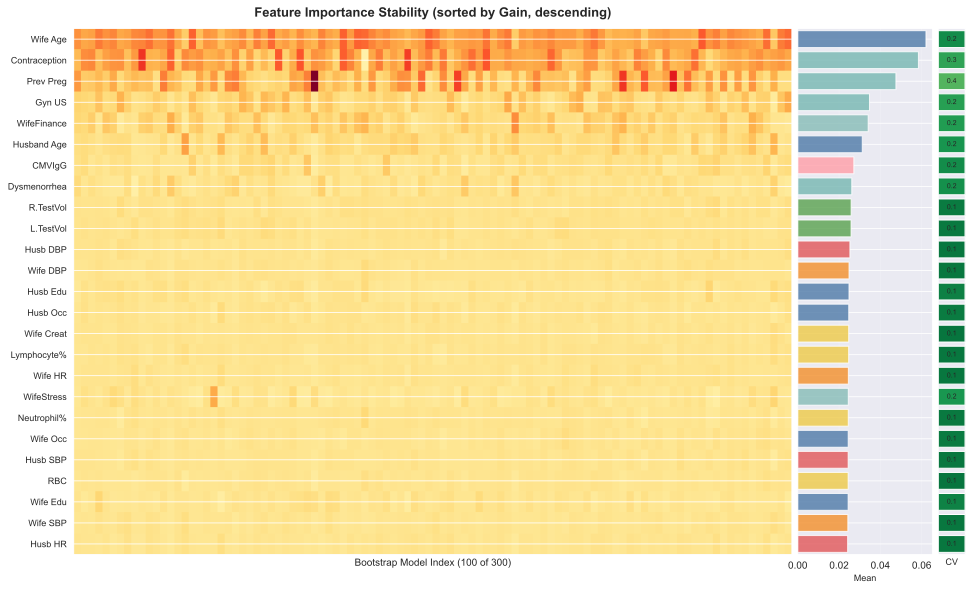

Saved: ./outputs_fi\importance_stability_heatmap.tiff


In [59]:
"""
§10 — Per-model heatmap + marginal mean bar + CV color strip
"""

n_hm = min(FI_TOP_N, 25)
top_feats_hm = df_fi.sort_values("Gain_Mean", ascending=False).head(n_hm)["Feature"].tolist()
top_idx_hm = [features.index(f) for f in top_feats_hm]
hm_data = gain_norm[:, top_idx_hm].T  # (n_feats, 300)

n_show = min(100, hm_data.shape[1])
model_idx_hm = np.linspace(0, hm_data.shape[1] - 1, n_show, dtype=int)
hm_sub = hm_data[:, model_idx_hm]

fig = plt.figure(figsize=(16, max(6, n_hm * 0.38)))
gs = gridspec.GridSpec(1, 3, width_ratios=[8, 1.5, 0.3], wspace=0.02)

ax_hm = fig.add_subplot(gs[0])
ax_hm.imshow(hm_sub, aspect="auto", cmap="YlOrRd", vmin=0)
ax_hm.set_yticks(range(n_hm))
ax_hm.set_yticklabels([_lbl(f) for f in top_feats_hm], fontsize=9)
ax_hm.set_xlabel(f"Bootstrap Model Index ({n_show} of {len(models)})", fontsize=10)
ax_hm.set_title("Feature Importance Stability (sorted by Gain, descending)",
                  fontsize=13, fontweight="bold", pad=12)
ax_hm.set_xticks([])

ax_bar = fig.add_subplot(gs[1], sharey=ax_hm)
means = hm_data.mean(axis=1)
ax_bar.barh(range(n_hm), means,
            color=[_GROUP_PALETTE.get(_grp(f), "#ccc") for f in top_feats_hm], alpha=0.8, height=0.8)
ax_bar.set_xlabel("Mean", fontsize=9)
ax_bar.tick_params(axis="y", left=False, labelleft=False)
ax_bar.grid(axis="x", alpha=0.2)

ax_cv = fig.add_subplot(gs[2], sharey=ax_hm)
cvs = [df_fi.loc[df_fi["Feature"] == f, "Gain_CV"].values[0] for f in top_feats_hm]
cv_colors = plt.cm.RdYlGn_r(np.clip(np.array(cvs) / 2.0, 0, 1))
for i, (c, cv) in enumerate(zip(cv_colors, cvs)):
    ax_cv.barh(i, 1, color=c, height=0.8)
    ax_cv.text(0.5, i, f"{cv:.1f}", ha="center", va="center", fontsize=7)
ax_cv.set_xlabel("CV", fontsize=9); ax_cv.set_xlim(0, 1); ax_cv.set_xticks([])
ax_cv.tick_params(axis="y", left=False, labelleft=False)

plt.tight_layout()
fpath = os.path.join(OUTPUT_DIR, "importance_stability_heatmap.tiff")
plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
plt.show(); print(f"Saved: {fpath}")

---
## §11 — Clinical Group Importance Summary

Clinical Group Importance:
                   N  Sum_Gain  Mean_Gain    Top_Feature  Sum_SHAP  Mean_SHAP
Group                                                                        
Lab Tests         10  0.241292   0.024129      WifeCreat  0.717827   0.071783
Demographics       8  0.237662   0.029708        WifeAge  0.568698   0.071087
Reproduction       4  0.166861   0.041715  Contraception  0.354545   0.088636
Wife Physical      4  0.097462   0.024366        WifeDBP  0.245242   0.061310
Husband Physical   4  0.097218   0.024304        HusbDBP  0.241673   0.060418
Psychosocial       3  0.080671   0.026890    WifeFinance  0.142925   0.047642
Andrology          2  0.051669   0.025834   RightTestVol  0.119842   0.059921
Infection          1  0.027165   0.027165         CMVIgG  0.035318   0.035318


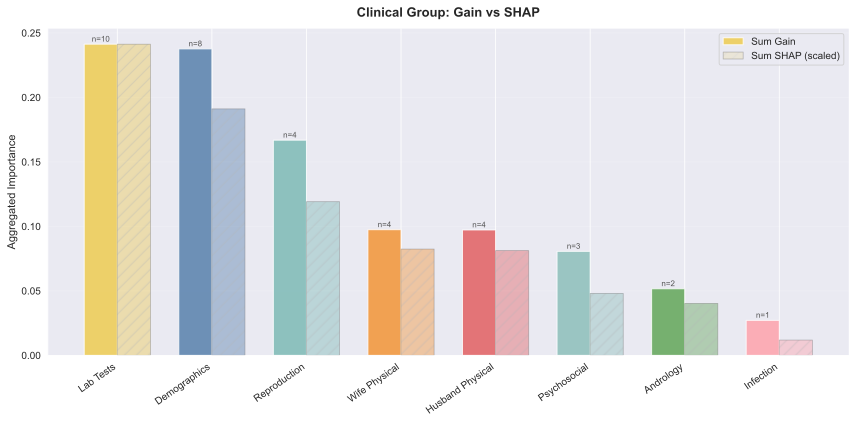

Saved: ./outputs_fi\group_importance.tiff


In [60]:
"""
§11 — Clinical Group: Gain vs SHAP grouped bar chart
"""

grp_agg = df_fi.groupby("Group").agg(
    N=("Feature", "count"),
    Sum_Gain=("Gain_Mean", "sum"),
    Mean_Gain=("Gain_Mean", "mean"),
    Top_Feature=("Gain_Mean", lambda x: df_fi.loc[x.idxmax(), "Feature"]),
).sort_values("Sum_Gain", ascending=False)

if SHAP_AVAILABLE:
    grp_agg = grp_agg.join(
        df_fi.groupby("Group").agg(Sum_SHAP=("SHAP_Train","sum"), Mean_SHAP=("SHAP_Train","mean"))
    )

print("Clinical Group Importance:")
print(grp_agg.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
grp_names = grp_agg.index.tolist()
x = np.arange(len(grp_names)); w = 0.35

ax.bar(x - w/2, grp_agg["Sum_Gain"].values, w, label="Sum Gain",
       color=[_GROUP_PALETTE.get(g, "#ccc") for g in grp_names], alpha=0.8, edgecolor="white")
if SHAP_AVAILABLE:
    scale = grp_agg["Sum_Gain"].max() / (grp_agg["Sum_SHAP"].max() + 1e-10)
    ax.bar(x + w/2, grp_agg["Sum_SHAP"].values * scale, w, label="Sum SHAP (scaled)",
           color=[_GROUP_PALETTE.get(g, "#ccc") for g in grp_names],
           alpha=0.4, edgecolor="#666", linewidth=0.8, hatch="//")

ax.set_xticks(x); ax.set_xticklabels(grp_names, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Aggregated Importance", fontsize=11)
ax.set_title("Clinical Group: Gain vs SHAP", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.2)
for i, (g, row) in enumerate(grp_agg.iterrows()):
    ax.text(i - w/2, row["Sum_Gain"] + 0.002, f"n={int(row['N'])}",
            ha="center", fontsize=8, color="#555")
sns.despine(); plt.tight_layout()
fpath = os.path.join(OUTPUT_DIR, "group_importance.tiff")
plt.savefig(fpath, dpi=FI_DPI, bbox_inches="tight")
plt.show(); print(f"Saved: {fpath}")

---
## §12 — SHAP Waterfall (Individual Explanations)

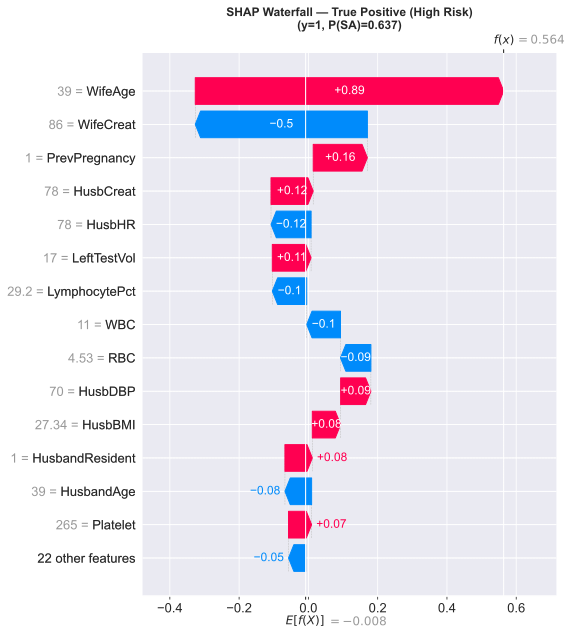

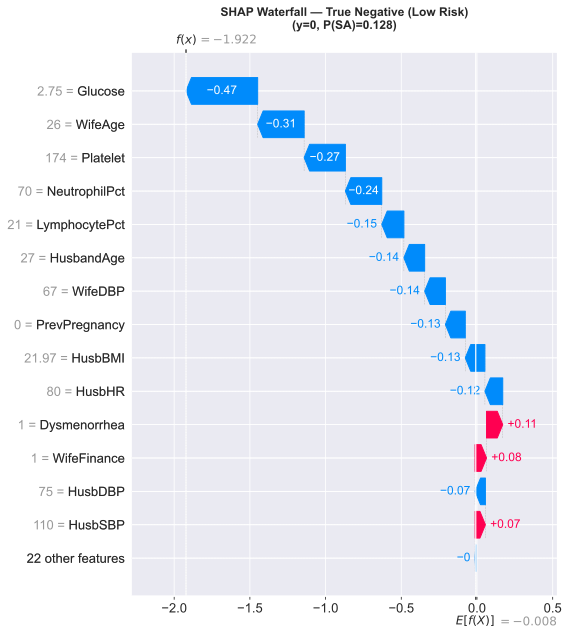

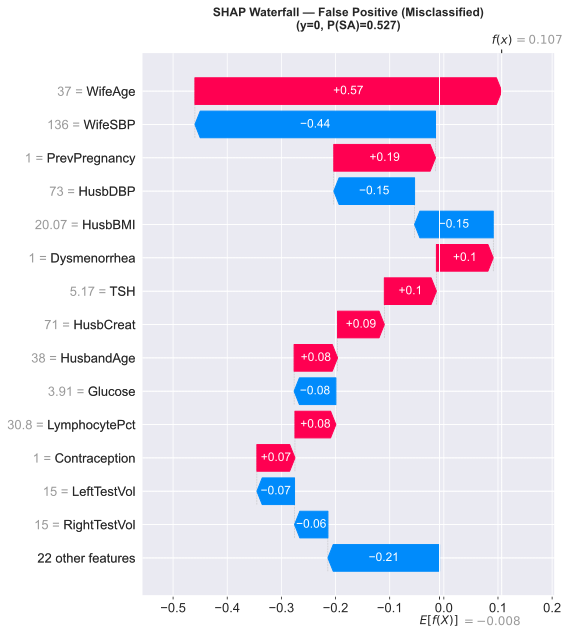

Waterfall plots: 3 samples


In [61]:
"""
§12 — Waterfall plots for representative TP / TN / FP samples
"""

if SHAP_AVAILABLE:
    y_sub = y_train.values[idx_shap_train] if hasattr(y_train, 'values') else y_train[idx_shap_train]
    prob_sub = models[0].predict_proba(X_shap_train)[:, 1]

    cases = {}
    tp = (y_sub == 1) & (prob_sub >= 0.5)
    tn = (y_sub == 0) & (prob_sub < 0.5)
    fp = (y_sub == 0) & (prob_sub >= 0.5)
    if tp.any(): cases["True Positive (High Risk)"] = np.where(tp)[0][0]
    if tn.any(): cases["True Negative (Low Risk)"] = np.where(tn)[0][0]
    if fp.any(): cases["False Positive (Misclassified)"] = np.where(fp)[0][0]

    explainer_wf = shap.TreeExplainer(models[0])
    explanation = explainer_wf(X_shap_train)

    for title, idx in cases.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        plt.sca(ax)
        bv = explanation.base_values[idx] if np.ndim(explanation.base_values) > 0 else explanation.base_values
        shap.waterfall_plot(
            shap.Explanation(values=explanation.values[idx], base_values=bv,
                              data=X_shap_train[idx], feature_names=features),
            max_display=15, show=False,
        )
        ax.set_title(f"SHAP Waterfall — {title}\n(y={y_sub[idx]}, P(SA)={prob_sub[idx]:.3f})",
                      fontsize=12, fontweight="bold")
        plt.tight_layout(); plt.show()
    print(f"Waterfall plots: {len(cases)} samples")
else:
    print("SHAP not available.")

---
## §13 — Export All Results to Excel

In [62]:
"""
§13 — Comprehensive Excel export (6 sheets)
"""

output_file = os.path.join(OUTPUT_DIR, "feature_importance_results.xlsx")

export_cols = ["Rank", "Feature", "Label", "Group",
               "Gain_Mean", "Gain_SD", "Gain_Median", "Gain_Q25", "Gain_Q75", "Gain_CV",
               "Weight_Mean", "Weight_SD", "N_Models_Used", "Usage_Rate"]
if SHAP_AVAILABLE:
    export_cols += ["SHAP_Train", "SHAP_Val", "SHAP_Test", "SHAP_SD", "SHAP_CI_Lo", "SHAP_CI_Hi"]
export_cols += ["Aggregated"]

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_fi[export_cols].to_excel(writer, sheet_name="Feature Importance", index=False)
    grp_agg.to_excel(writer, sheet_name="Group Summary")

    top30 = df_fi.head(30)["Feature"].tolist()
    top30_idx = [features.index(f) for f in top30]
    pd.DataFrame(gain_norm[:, top30_idx], columns=top30).to_excel(
        writer, sheet_name="Gain Matrix (Top 30)", index_label="Model")

    pd.DataFrame({
        "Feature": features, "Label": [_lbl(f) for f in features],
        "Gain_Mean": gain_norm.mean(axis=0), "Gain_SD": gain_norm.std(axis=0),
        "CV": gain_norm.std(axis=0) / (gain_norm.mean(axis=0) + 1e-10),
        "N_Models_Used": (gain_raw > 0).sum(axis=0),
        "Usage_Rate_Pct": (gain_raw > 0).sum(axis=0) / len(models) * 100,
    }).sort_values("Gain_Mean", ascending=False).to_excel(
        writer, sheet_name="Model Consistency", index=False)

    if SHAP_AVAILABLE:
        df_fi[["Rank","Feature","Label","SHAP_Train","SHAP_Val","SHAP_Test",
               "SHAP_SD","SHAP_CI_Lo","SHAP_CI_Hi"]].to_excel(
            writer, sheet_name="SHAP Cross-Split", index=False)

    rank_corr.to_excel(writer, sheet_name="Method Correlation")

print(f"Saved: {output_file}")

# ── Final Summary ──
print(f"\n{'=' * 70}")
print("FEATURE IMPORTANCE ANALYSIS COMPLETE")
print(f"{'=' * 70}")
print(f"  Models: {len(models)} bootstrap XGBoost")
print(f"  Features: {len(features)}")
print(f"  Methods: Gain, Weight" + (", SHAP (per-split + interactions)" if SHAP_AVAILABLE else ""))
print(f"\n  Top 5 (Aggregated):")
for _, row in df_fi.head(5).iterrows():
    line = f"    {row['Rank']:2.0f}. {row['Label']:20s}  Gain={row['Gain_Mean']:.4f}"
    if SHAP_AVAILABLE:
        line += f"  SHAP={row['SHAP_Train']:.4f}  (Val={row['SHAP_Val']:.4f}, Test={row['SHAP_Test']:.4f})"
    print(line)
print(f"\n  Output: {OUTPUT_DIR}/")
print(f"  Figures: {len([f for f in os.listdir(OUTPUT_DIR) if f.endswith('.tiff')])} TIFF files")

Saved: ./outputs_fi\feature_importance_results.xlsx

FEATURE IMPORTANCE ANALYSIS COMPLETE
  Models: 300 bootstrap XGBoost
  Features: 36
  Methods: Gain, Weight, SHAP (per-split + interactions)

  Top 5 (Aggregated):
     1. Wife Age              Gain=0.0621  SHAP=0.3132  (Val=0.3282, Test=0.3115)
     2. Contraception         Gain=0.0584  SHAP=0.1085  (Val=0.1112, Test=0.0943)
     3. Prev Preg             Gain=0.0475  SHAP=0.1300  (Val=0.1289, Test=0.1216)
     4. TSH                   Gain=0.0240  SHAP=0.0864  (Val=0.0808, Test=0.1262)
     5. Husband Age           Gain=0.0312  SHAP=0.1067  (Val=0.0922, Test=0.0915)

  Output: ./outputs_fi/
  Figures: 8 TIFF files
